In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [14]:
load_dotenv()

model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash-lite')

In [15]:
# Create the State
class LLMBlog(TypedDict):
    topic : str
    outline : str
    blog : str

In [16]:
def llm_outline(state: LLMBlog) -> LLMBlog:

    # Extract the topic from the State
    topic = state['topic']

    # Create a prompt
    prompt = f"Generate the outline on the topic - {topic}"

    # Call the LLM
    result1 = model.invoke(prompt).content

    # Change the State
    state['outline'] = result1

    return state

In [17]:
def llm_blog(state: LLMBlog) -> LLMBlog:

    # Extract the topic from the State
    outlines = state['outline']

    # Create a prompt
    prompt = f"Generate the detailed blog on the outline in (50 words) - {outlines}"

    # Call the LLM
    result2 = model.invoke(prompt).content

    # Change the State
    state['blog'] = result2

    return state

In [18]:
# Create the graph
graph = StateGraph(LLMBlog)

# Create the node
graph.add_node('outline', llm_outline)
graph.add_node('detailed_blog', llm_blog)

# Create the edges
graph.add_edge(START, 'outline')
graph.add_edge('outline', 'detailed_blog')
graph.add_edge('detailed_blog', END)


# Compile the Graph
workflow = graph.compile()

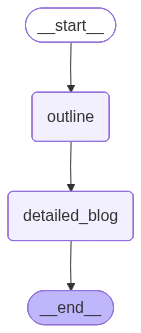

In [19]:
workflow

In [20]:
initial_state = {'topic' : 'EV Cars'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'topic': 'EV Cars', 'outline': '## Outline: Electric Vehicles (EVs) - The Future of Transportation\n\n**I. Introduction**\n    A. Hook: The growing presence and impact of EVs on our roads.\n    B. Definition of Electric Vehicles (EVs): What they are and how they differ from traditional internal combustion engine (ICE) vehicles.\n    C. Thesis Statement: Electric vehicles represent a pivotal shift in automotive technology, offering significant environmental, economic, and technological advantages that are reshaping the future of transportation.\n    D. Roadmap of the Presentation/Essay: Briefly outline the key areas to be covered.\n\n**II. The Technology Behind Electric Vehicles**\n    A. Core Components:\n        1. Battery Pack:\n            a. Types of Batteries (e.g., Lithium-ion, Solid-state)\n            b. Battery Management System (BMS)\n            c. Capacity and Range\n        2. Electric Motor:\n            a. Types of Motors (e.g., AC Induction, Permanent Magnet Synchronou

In [24]:
print(final_state['blog'])

## Electric Vehicles: Powering the Future of Transportation

The hum of electric motors is becoming an increasingly familiar sound on our roads, signaling a profound shift in how we move. But what exactly are these vehicles, and how do they differ from the gasoline-powered cars we've known for decades? Electric Vehicles (EVs) are automobiles powered by electricity stored in rechargeable battery packs, offering a compelling alternative to traditional internal combustion engine (ICE) vehicles. This blog will delve into the revolutionary technology, undeniable advantages, persistent challenges, and the exciting future of EVs, demonstrating their pivotal role in shaping transportation for generations to come.

### The Engine of Tomorrow: Unpacking EV Technology

At the heart of every EV lies a sophisticated interplay of components designed for efficient, clean propulsion. The **battery pack**, typically lithium-ion, acts as the vehicle's energy reservoir, its capacity dictating the car's r

In [23]:
print(final_state['outline'])

## Outline: Electric Vehicles (EVs) - The Future of Transportation

**I. Introduction**
    A. Hook: The growing presence and impact of EVs on our roads.
    B. Definition of Electric Vehicles (EVs): What they are and how they differ from traditional internal combustion engine (ICE) vehicles.
    C. Thesis Statement: Electric vehicles represent a pivotal shift in automotive technology, offering significant environmental, economic, and technological advantages that are reshaping the future of transportation.
    D. Roadmap of the Presentation/Essay: Briefly outline the key areas to be covered.

**II. The Technology Behind Electric Vehicles**
    A. Core Components:
        1. Battery Pack:
            a. Types of Batteries (e.g., Lithium-ion, Solid-state)
            b. Battery Management System (BMS)
            c. Capacity and Range
        2. Electric Motor:
            a. Types of Motors (e.g., AC Induction, Permanent Magnet Synchronous)
            b. Torque and Efficiency
        